In [2]:
# ===========================================
# Libraries imports
# ===========================================

import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [3]:
# ===========================================
# Plot configuration
# ===========================================

plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="viridis",
    font_scale=1.1
)

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["figure.dpi"] = 120

In [4]:
# ===========================================
# Dataset loading
# ===========================================

df = pd.read_csv("FIFA_World_Cup_Champions_1930_2022.csv")

In [5]:
df.head()

,year,host_country,host_city_final,stadium,winner,runner_up,winner_captain,winner_head_coach,win_method,winner_goals,...,matches_played,winner_titles_after_win,continent_winner,golden_ball,golden_boot,best_young_player,golden_glove,top_scorer_goals,mascot,official_ball
0,1930,Uruguay,Montevideo,Estadio Centenario,Uruguay,Argentina,José Nasazzi,Alberto Suppici,Regular Time,4,...,18,1,South America,NaN,Guillermo Stábile,NaN,NaN,8,NaN,T-Model
1,1934,Italy,Rome,Stadio Nazionale PNF,Italy,Czechoslovakia,Gianpiero Combi,Vittorio Pozzo,Extra Time,2,...,17,1,Europe,NaN,Oldřich Nejedlý,NaN,NaN,5,NaN,Federale 102
2,1938,France,Paris,Stade Olympique de Colombes,Italy,Hungary,Giuseppe Meazza,Vittorio Pozzo,Regular Time,4,...,18,2,Europe,NaN,Leônidas,NaN,NaN,7,NaN,Allen
3,1950,Brazil,Rio de Janeiro,Maracanã,Uruguay,Brazil,Obdulio Varela,Juan López Fontana,Regular Time,2,...,22,2,South America,NaN,Ademir,NaN,NaN,9,NaN,Super Duplo T
4,1954,Switzerland,Bern,Wankdorf Stadium,West Germany,Hungary,Fritz Walter,Sepp Herberger,Regular Time,3,...,26,1,Europe,NaN,Sándor Kocsis,NaN,NaN,11,NaN,Swiss World Champion


In [6]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 22
Number of columns: 23


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   year                     22 non-null     int64
 1   host_country             22 non-null     str  
 2   host_city_final          22 non-null     str  
 3   stadium                  22 non-null     str  
 4   winner                   22 non-null     str  
 5   runner_up                22 non-null     str  
 6   winner_captain           22 non-null     str  
 7   winner_head_coach        22 non-null     str  
 8   win_method               22 non-null     str  
 9   winner_goals             22 non-null     int64
 10  runner_up_goals          22 non-null     int64
 11  attendance               22 non-null     int64
 12  total_teams              22 non-null     int64
 13  matches_played           22 non-null     int64
 14  winner_titles_after_win  22 non-null     int64
 15  continent_winner   

In [8]:
df.describe()

,year,winner_goals,runner_up_goals,attendance,total_teams,matches_played,winner_titles_after_win,top_scorer_goals
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,1978.909091,2.636364,1.136364,81534.636364,22.227273,43.818182,2.227273,7.136364
std,27.738419,1.292670,0.888844,26831.765955,7.602830,17.632860,1.231794,2.188617
min,1930.000000,0.000000,0.000000,45000.000000,13.000000,17.000000,1.000000,4.000000
25%,1959.000000,2.000000,0.250000,68759.250000,16.000000,32.000000,1.000000,6.000000
50%,1980.000000,3.000000,1.000000,76374.500000,20.000000,45.000000,2.000000,6.000000
75%,2001.000000,3.750000,2.000000,89741.500000,32.000000,64.000000,3.000000,8.000000
max,2022.000000,5.000000,3.000000,173850.000000,32.000000,64.000000,5.000000,13.000000


In [9]:
df.describe(include="object")

,host_country,host_city_final,stadium,winner,runner_up,winner_captain,winner_head_coach,win_method,continent_winner,golden_ball,golden_boot,best_young_player,golden_glove,mascot,official_ball
count,22,22,22,22,22,22,22,22,22,11,22,5,8,15,22
unique,18,19,19,9,11,22,21,3,2,10,22,5,8,15,22
top,Italy,Rome,Maracanã,Brazil,Argentina,José Nasazzi,Vittorio Pozzo,Regular Time,Europe,Lionel Messi,Guillermo Stábile,Lukas Podolski,Michel Preud'homme,World Cup Willie,T-Model
freq,2,2,2,5,3,1,2,14,12,2,1,1,1,1,1


In [10]:
for coluna in df.columns:
    print(coluna)

year
host_country
host_city_final
stadium
winner
runner_up
winner_captain
winner_head_coach
win_method
winner_goals
runner_up_goals
attendance
total_teams
matches_played
winner_titles_after_win
continent_winner
golden_ball
golden_boot
best_young_player
golden_glove
top_scorer_goals
mascot
official_ball


In [11]:
df.sample(5, random_state=42)

,year,host_country,host_city_final,stadium,winner,runner_up,winner_captain,winner_head_coach,win_method,winner_goals,...,matches_played,winner_titles_after_win,continent_winner,golden_ball,golden_boot,best_young_player,golden_glove,top_scorer_goals,mascot,official_ball
0,1930,Uruguay,Montevideo,Estadio Centenario,Uruguay,Argentina,José Nasazzi,Alberto Suppici,Regular Time,4,...,18,1,South America,NaN,Guillermo Stábile,NaN,NaN,8,NaN,T-Model
13,1990,Italy,Rome,Stadio Olimpico,West Germany,Argentina,Lothar Matthäus,Franz Beckenbauer,Regular Time,1,...,52,3,Europe,Salvatore Schillaci,Salvatore Schillaci,NaN,NaN,6,Ciao,Etrusco Unico
8,1970,Mexico,Mexico City,Estadio Azteca,Brazil,Italy,Carlos Alberto Torres,Mário Zagallo,Regular Time,4,...,32,3,South America,NaN,Gerd Müller,NaN,NaN,10,Juanito,Telstar
1,1934,Italy,Rome,Stadio Nazionale PNF,Italy,Czechoslovakia,Gianpiero Combi,Vittorio Pozzo,Extra Time,2,...,17,1,Europe,NaN,Oldřich Nejedlý,NaN,NaN,5,NaN,Federale 102
15,1998,France,Saint-Denis,Stade de France,France,Brazil,Didier Deschamps,Aimé Jacquet,Regular Time,3,...,64,1,Europe,Ronaldo,Davor Šuker,NaN,Fabien Barthez,6,Footix,Tricolore


In [12]:
# ===========================================
# Missing values by column
# ===========================================

missing_values = df.isna().sum()

missing_values

year                        0
host_country                0
host_city_final             0
stadium                     0
winner                      0
runner_up                   0
winner_captain              0
winner_head_coach           0
win_method                  0
winner_goals                0
runner_up_goals             0
attendance                  0
total_teams                 0
matches_played              0
winner_titles_after_win     0
continent_winner            0
golden_ball                11
golden_boot                 0
best_young_player          17
golden_glove               14
top_scorer_goals            0
mascot                      7
official_ball               0
dtype: int64

In [13]:
# ===========================================
# Percentage of missing values
# ===========================================

missing_percentage = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_percentage

best_young_player          77.272727
golden_glove               63.636364
golden_ball                50.000000
mascot                     31.818182
year                        0.000000
host_country                0.000000
host_city_final             0.000000
winner_captain              0.000000
runner_up                   0.000000
winner                      0.000000
stadium                     0.000000
winner_head_coach           0.000000
win_method                  0.000000
winner_goals                0.000000
runner_up_goals             0.000000
winner_titles_after_win     0.000000
matches_played              0.000000
total_teams                 0.000000
attendance                  0.000000
golden_boot                 0.000000
continent_winner            0.000000
top_scorer_goals            0.000000
official_ball               0.000000
dtype: float64

In [14]:
# ===========================================
# Data quality summary
# ===========================================

data_quality = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Percentage (%)": (df.isna().mean() * 100).round(2),
    "Data Type": df.dtypes
})

data_quality.sort_values(
    by="Percentage (%)",
    ascending=False
)

,Missing Values,Percentage (%),Data Type
best_young_player,17,77.27,str
golden_glove,14,63.64,str
golden_ball,11,50.00,str
mascot,7,31.82,str
year,0,0.00,int64
host_country,0,0.00,str
host_city_final,0,0.00,str
winner_captain,0,0.00,str
runner_up,0,0.00,str
winner,0,0.00,str


In [15]:
# ===========================================
# Overall dataset completeness
# ===========================================

total_cells = df.shape[0] * df.shape[1]

total_missing = df.isna().sum().sum()

completeness_percentage = (
    (1 - total_missing / total_cells) * 100
)

print(f"Total cells: {total_cells}")
print(f"Missing values: {total_missing}")
print(f"Overall completeness: {completeness_percentage:.2f}%")

Total cells: 506
Missing values: 49
Overall completeness: 90.32%


In [16]:
# ===========================================
# Duplicate records
# ===========================================

duplicate_rows = df.duplicated().sum()

print(f"Duplicate records: {duplicate_rows}")

Duplicate records: 0


In [17]:
# ===========================================
# Display duplicate records
# ===========================================

duplicates = df[df.duplicated()]

duplicates

,year,host_country,host_city_final,stadium,winner,runner_up,winner_captain,winner_head_coach,win_method,winner_goals,...,matches_played,winner_titles_after_win,continent_winner,golden_ball,golden_boot,best_young_player,golden_glove,top_scorer_goals,mascot,official_ball


In [18]:
# ===========================================
# Remove duplicate records
# ===========================================

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate records removed successfully.")

Duplicate records removed successfully.


In [19]:
# ===========================================
# Current column names
# ===========================================

df.columns.tolist()

['year',
 'host_country',
 'host_city_final',
 'stadium',
 'winner',
 'runner_up',
 'winner_captain',
 'winner_head_coach',
 'win_method',
 'winner_goals',
 'runner_up_goals',
 'attendance',
 'total_teams',
 'matches_played',
 'winner_titles_after_win',
 'continent_winner',
 'golden_ball',
 'golden_boot',
 'best_young_player',
 'golden_glove',
 'top_scorer_goals',
 'mascot',
 'official_ball']

In [20]:
# ===========================================
# Standardize column names
# ===========================================

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.columns.tolist()

['year',
 'host_country',
 'host_city_final',
 'stadium',
 'winner',
 'runner_up',
 'winner_captain',
 'winner_head_coach',
 'win_method',
 'winner_goals',
 'runner_up_goals',
 'attendance',
 'total_teams',
 'matches_played',
 'winner_titles_after_win',
 'continent_winner',
 'golden_ball',
 'golden_boot',
 'best_young_player',
 'golden_glove',
 'top_scorer_goals',
 'mascot',
 'official_ball']

In [21]:
# ===========================================
# Inspect data types
# ===========================================

df.dtypes

year                       int64
host_country                 str
host_city_final              str
stadium                      str
winner                       str
runner_up                    str
winner_captain               str
winner_head_coach            str
win_method                   str
winner_goals               int64
runner_up_goals            int64
attendance                 int64
total_teams                int64
matches_played             int64
winner_titles_after_win    int64
continent_winner             str
golden_ball                  str
golden_boot                  str
best_young_player            str
golden_glove                 str
top_scorer_goals           int64
mascot                       str
official_ball                str
dtype: object

In [22]:
# ===========================================
# Convert year to integer
# ===========================================

df["year"] = df["year"].astype(int)

In [23]:
df["year"].dtype

dtype('int64')

In [24]:
# ===========================================
# Standardize text columns
# ===========================================

text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].str.strip()

In [25]:
# ===========================================
# Unique values in categorical columns
# ===========================================

for column in text_columns:
    print(f"\n{column}")
    print("-" * len(column))
    print(df[column].nunique())


host_country
------------
18

host_city_final
---------------
19

stadium
-------
19

winner
------
9

runner_up
---------
11

winner_captain
--------------
22

winner_head_coach
-----------------
21

win_method
----------
3

continent_winner
----------------
2

golden_ball
-----------
10

golden_boot
-----------
22

best_young_player
-----------------
5

golden_glove
------------
8

mascot
------
15

official_ball
-------------
22


In [26]:
# ===========================================
# Unique values of selected columns
# ===========================================

categorical_columns = [
    "winner",
    "runner_up",
    "host_country",
    "continent_winner"
]

for column in categorical_columns:
    print(f"\n{'=' * 60}")
    print(column.upper())
    print(f"{'=' * 60}")
    print(sorted(df[column].unique()))


WINNER
['Argentina', 'Brazil', 'England', 'France', 'Germany', 'Italy', 'Spain', 'Uruguay', 'West Germany']

RUNNER_UP
['Argentina', 'Brazil', 'Croatia', 'Czechoslovakia', 'France', 'Germany', 'Hungary', 'Italy', 'Netherlands', 'Sweden', 'West Germany']

HOST_COUNTRY
['Argentina', 'Brazil', 'Chile', 'England', 'France', 'Germany', 'Italy', 'Mexico', 'Qatar', 'Russia', 'South Africa', 'South Korea/Japan', 'Spain', 'Sweden', 'Switzerland', 'United States', 'Uruguay', 'West Germany']

CONTINENT_WINNER
['Europe', 'South America']


In [27]:
# ===========================================
# Numerical variables
# ===========================================

numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical variables:")

for column in numerical_columns:
    print(f"- {column}")

Numerical variables:
- year
- winner_goals
- runner_up_goals
- attendance
- total_teams
- matches_played
- winner_titles_after_win
- top_scorer_goals


In [28]:
# ===========================================
# Statistical summary
# ===========================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,22.0,1978.909091,27.738419,1930.0,1959.00,1980.0,2001.00,2022.0
winner_goals,22.0,2.636364,1.292670,0.0,2.00,3.0,3.75,5.0
runner_up_goals,22.0,1.136364,0.888844,0.0,0.25,1.0,2.00,3.0
attendance,22.0,81534.636364,26831.765955,45000.0,68759.25,76374.5,89741.50,173850.0
total_teams,22.0,22.227273,7.602830,13.0,16.00,20.0,32.00,32.0
matches_played,22.0,43.818182,17.632860,17.0,32.00,45.0,64.00,64.0
winner_titles_after_win,22.0,2.227273,1.231794,1.0,1.00,2.0,3.00,5.0
top_scorer_goals,22.0,7.136364,2.188617,4.0,6.00,6.0,8.00,13.0


In [29]:
# ===========================================
# Central tendency measures
# ===========================================

mean = df[numerical_columns].mean()

median = df[numerical_columns].median()

mode = df[numerical_columns].mode().iloc[0]

In [30]:
# ===========================================
# Variability measures
# ===========================================

variance = df[numerical_columns].var()

standard_deviation = df[numerical_columns].std()

data_range = (
    df[numerical_columns].max()
    - df[numerical_columns].min()
)

In [31]:
# ===========================================
# Quartiles
# ===========================================

quartiles = df[numerical_columns].quantile(
    [0.25, 0.50, 0.75]
)

quartiles

,year,winner_goals,runner_up_goals,attendance,total_teams,matches_played,winner_titles_after_win,top_scorer_goals
0.25,1959.0,2.00,0.25,68759.25,16.0,32.0,1.0,6.0
0.50,1980.0,3.00,1.00,76374.50,20.0,45.0,2.0,6.0
0.75,2001.0,3.75,2.00,89741.50,32.0,64.0,3.0,8.0


In [32]:
# ===========================================
# Selected percentiles
# ===========================================

percentiles = df[numerical_columns].quantile(
    [0.05, 0.10, 0.90, 0.95]
)

percentiles

,year,winner_goals,runner_up_goals,attendance,total_teams,matches_played,winner_titles_after_win,top_scorer_goals
0.05,1934.2,1.0,0.0,50000.15,13.1,18.0,1.0,5.00
0.10,1939.2,1.0,0.0,55750.00,15.1,18.4,1.0,5.00
0.90,2013.6,4.0,2.0,106363.20,32.0,64.0,4.0,9.90
0.95,2017.8,4.0,2.0,114240.60,32.0,64.0,4.0,10.95


In [33]:
# ===========================================
# Coefficient of variation
# ===========================================

coefficient_variation = (
    standard_deviation
    / mean
) * 100

coefficient_variation

year                        1.401703
winner_goals               49.032309
runner_up_goals            78.218254
attendance                 32.908427
total_teams                34.204963
matches_played             40.240967
winner_titles_after_win    55.305029
top_scorer_goals           30.668515
dtype: float64

In [34]:
# ===========================================
# Complete descriptive statistics table
# ===========================================

descriptive_statistics = pd.DataFrame({
    "Mean": mean,
    "Median": median,
    "Mode": mode,
    "Variance": variance,
    "Standard Deviation": standard_deviation,
    "Range": data_range,
    "Coefficient of Variation (%)": coefficient_variation
})

descriptive_statistics = descriptive_statistics.round(2)

descriptive_statistics

,Mean,Median,Mode,Variance,Standard Deviation,Range,Coefficient of Variation (%)
year,1978.91,1980.0,1930.0,7.694200e+02,27.74,92,1.40
winner_goals,2.64,3.0,3.0,1.670000e+00,1.29,5,49.03
runner_up_goals,1.14,1.0,1.0,7.900000e-01,0.89,3,78.22
attendance,81534.64,76374.5,45000.0,7.199437e+08,26831.77,128850,32.91
total_teams,22.23,20.0,16.0,5.780000e+01,7.60,19,34.20
matches_played,43.82,45.0,64.0,3.109200e+02,17.63,47,40.24
winner_titles_after_win,2.23,2.0,1.0,1.520000e+00,1.23,4,55.31
top_scorer_goals,7.14,6.0,6.0,4.790000e+00,2.19,9,30.67


In [35]:
# ===========================================
# Function to visualize numerical variables
# ===========================================

def plot_distribution(dataframe, column):

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(16, 6)
    )

    sns.histplot(
        data=dataframe,
        x=column,
        bins="auto",
        kde=True,
        ax=axes[0],
        color="steelblue"
    )

    axes[0].set_title(f"Distribution of {column}")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Frequency")

    sns.boxplot(
        data=dataframe,
        x=column,
        ax=axes[1],
        color="lightcoral"
    )

    axes[1].set_title(f"Boxplot of {column}")
    axes[1].set_xlabel(column)

    plt.tight_layout()

    plt.show()

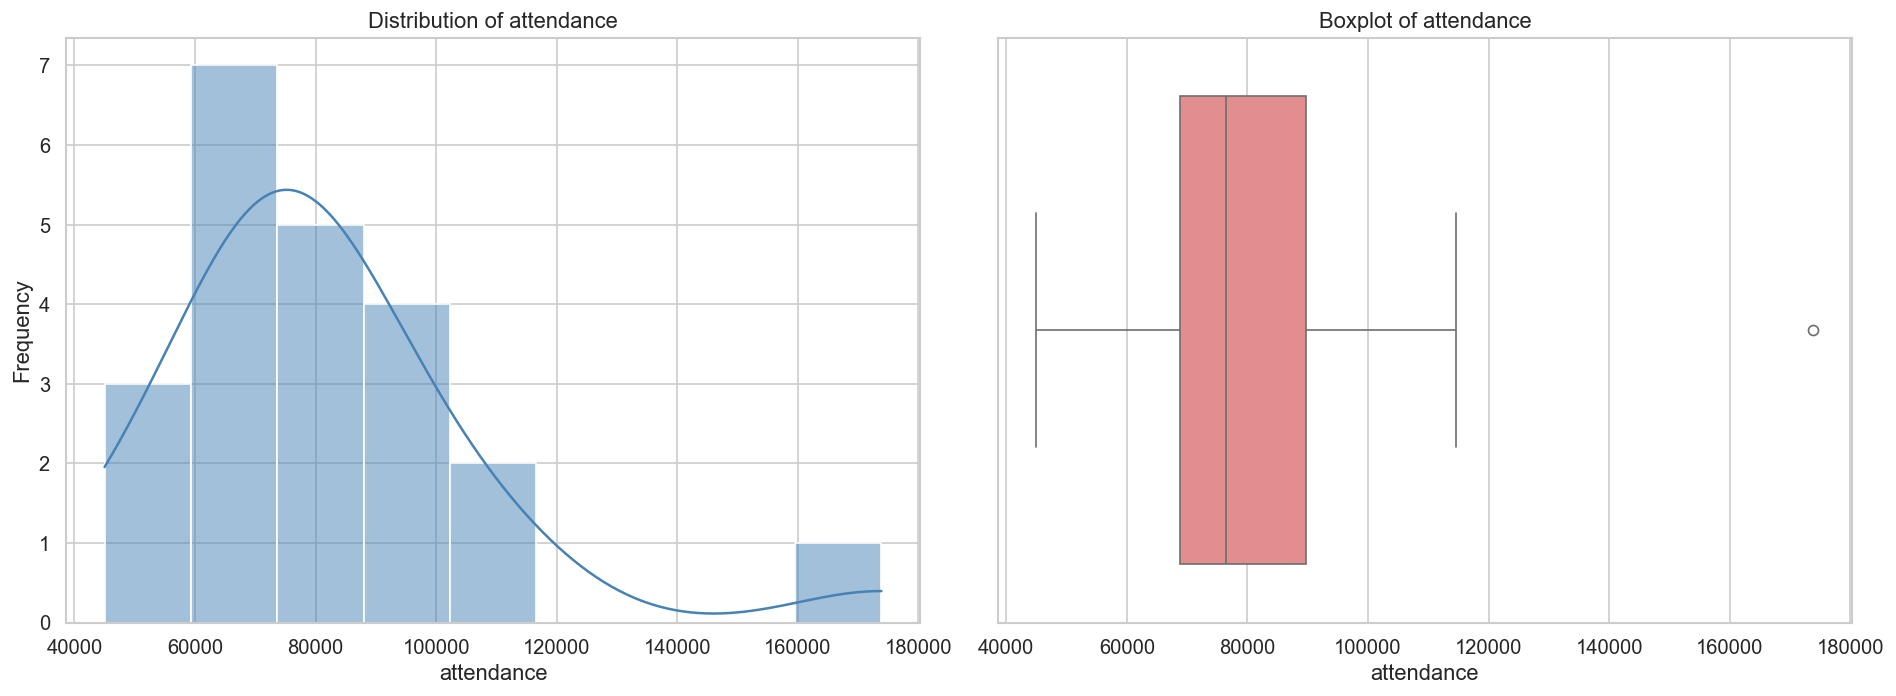

In [36]:
plot_distribution(df, "attendance")

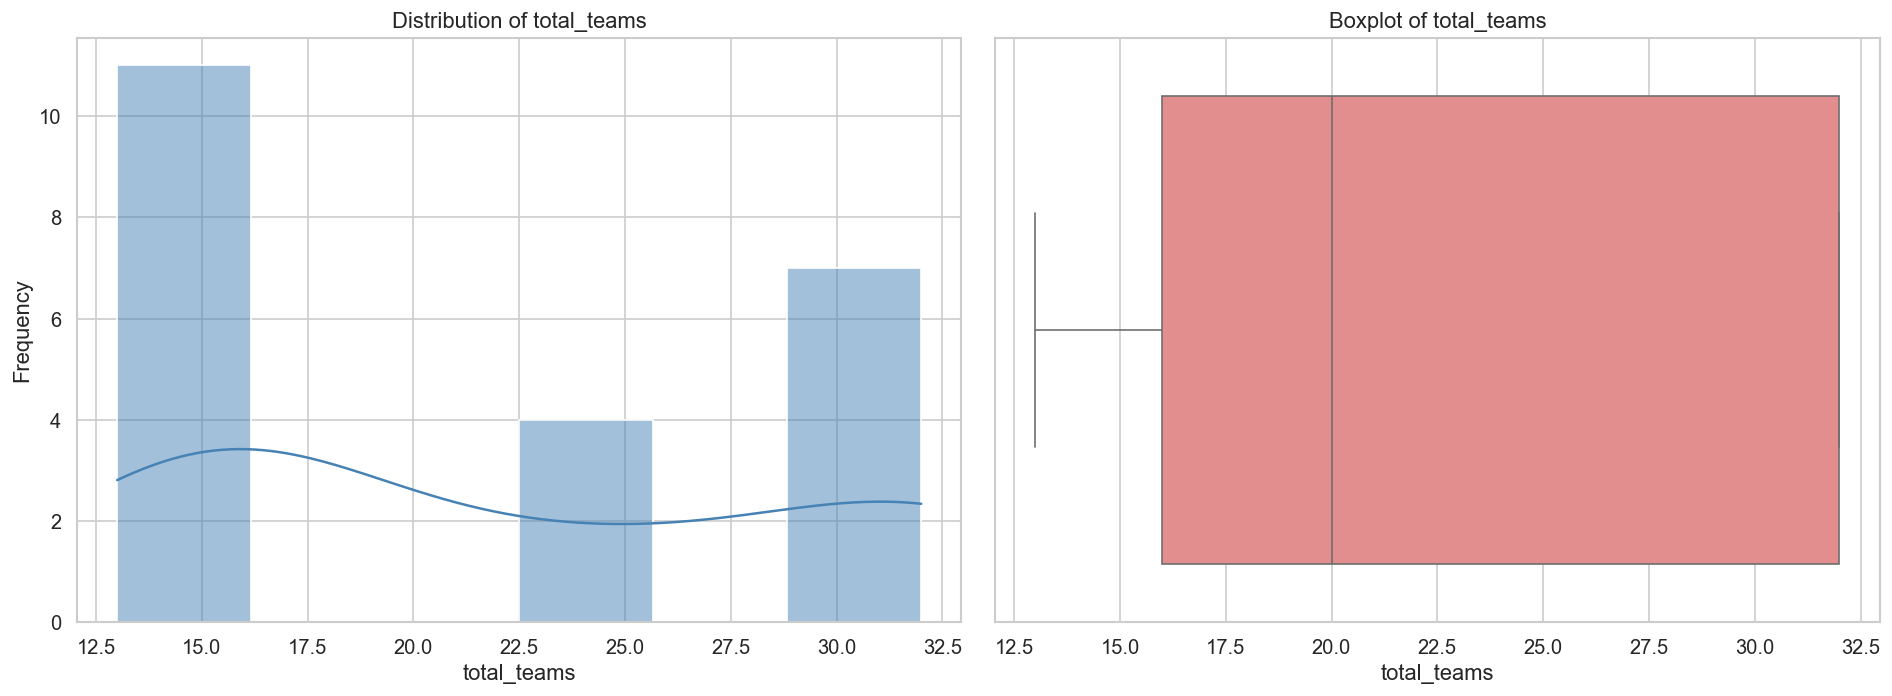

In [37]:
plot_distribution(df, "total_teams")

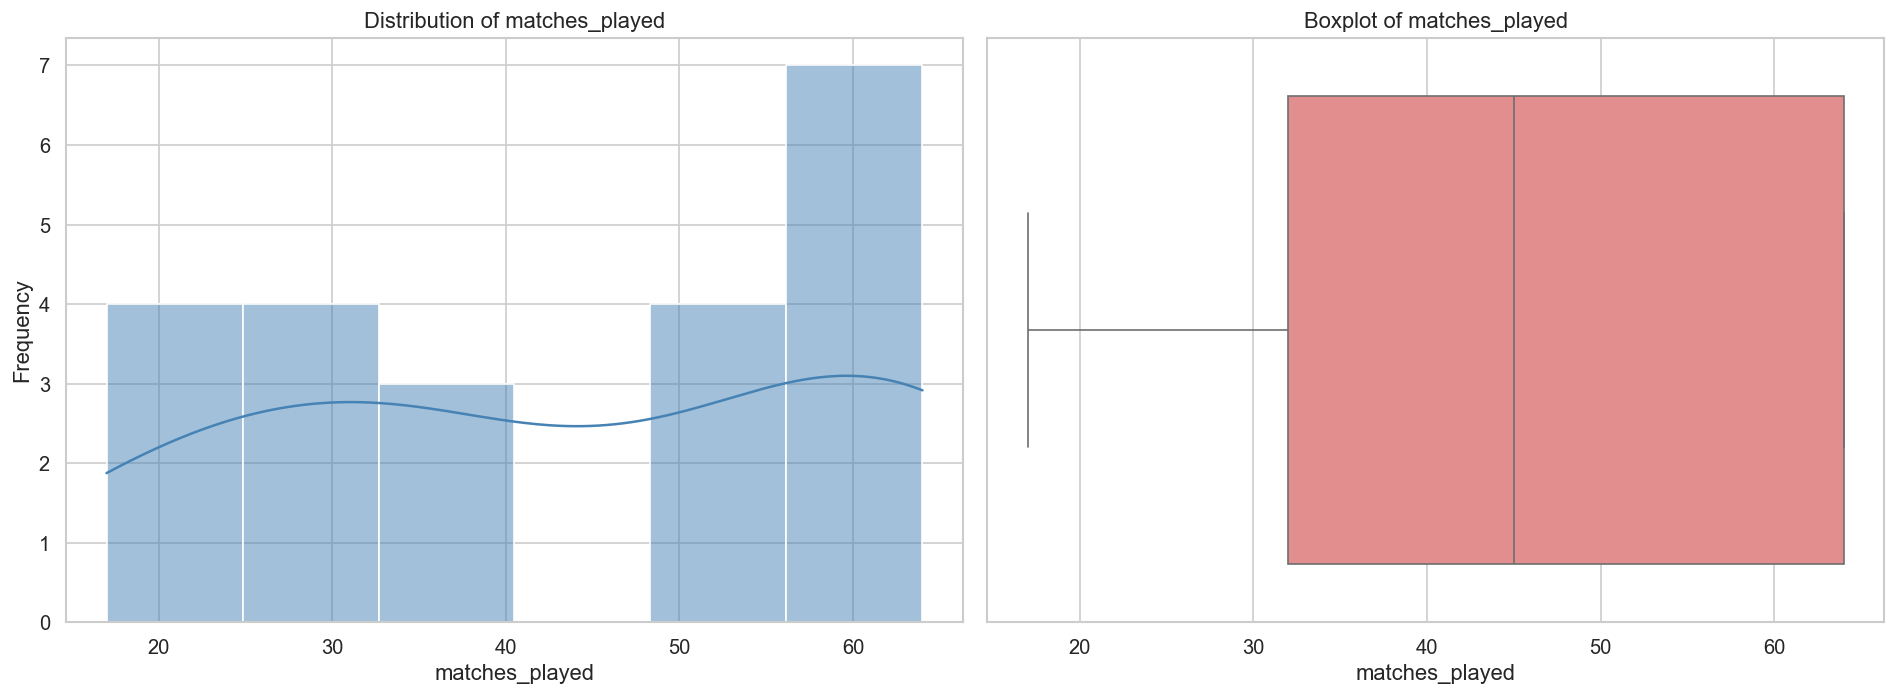

In [38]:
plot_distribution(df, "matches_played")

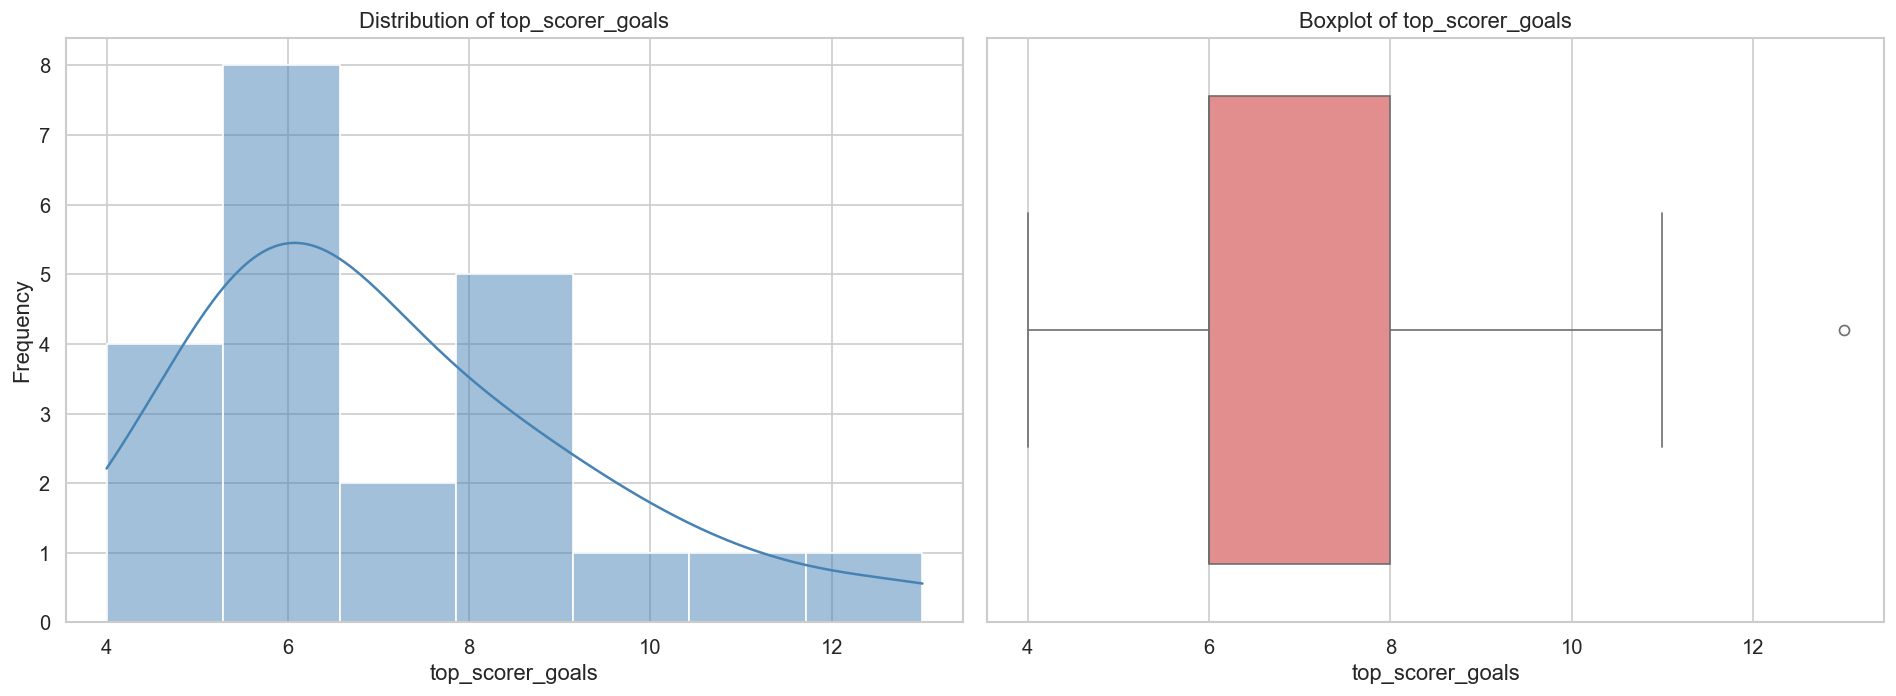

In [39]:
plot_distribution(df, "top_scorer_goals")

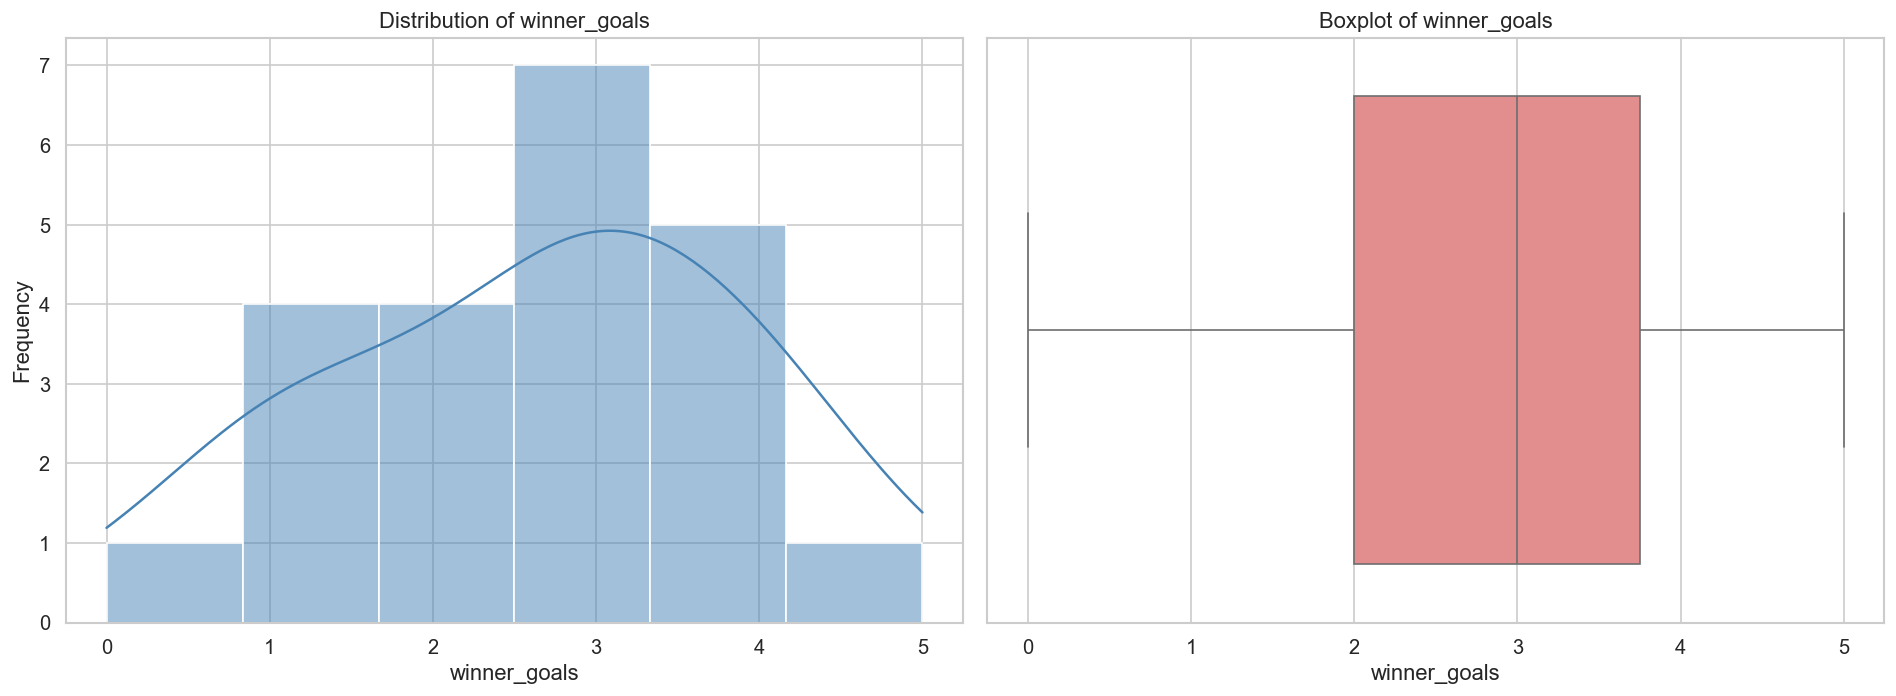

In [40]:
plot_distribution(df, "winner_goals")

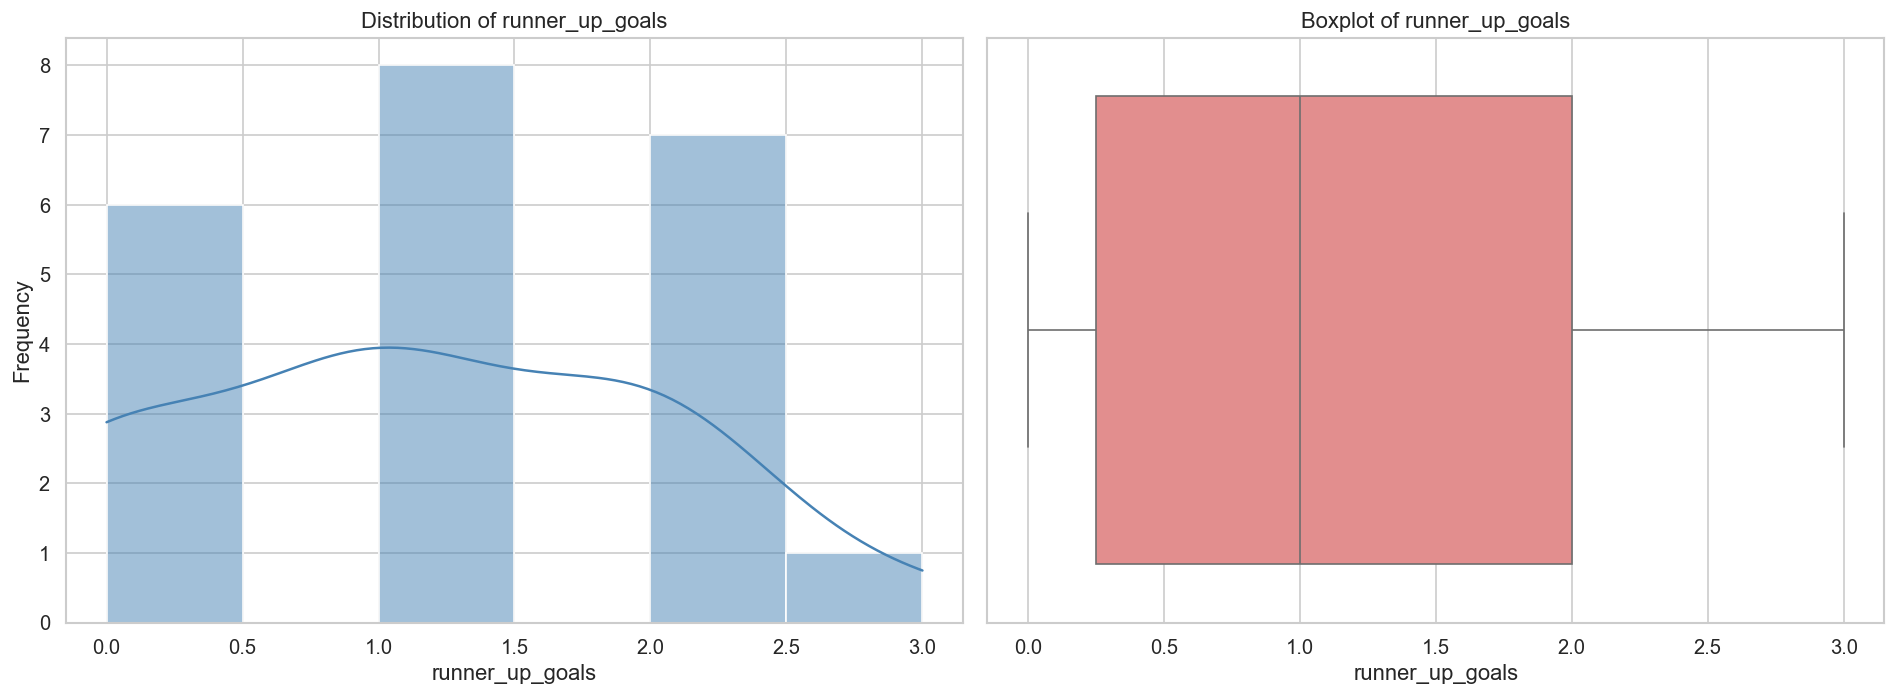

In [41]:
plot_distribution(df, "runner_up_goals")